In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "For alias generation (judgement ①), how correct is each model in the roster — scored against Opus-as-truth and RxNorm — and how do the models diverge from one another?"

*Judgement ① of 11 · the archetype factual test, now across the full lab roster: correctness vs two truth sources, an N×N divergence map, and a price-aware scorecard. Numbers are computed from the run.*

In [2]:

import json
from itertools import combinations
from scipy.stats import spearmanr

RUNS = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j1_alias_runs.json", encoding="utf-8"))
MAN = RUNS["manifest"]
gens, judge, rxn = RUNS["generations"], RUNS["judge"], RUNS["rxnorm"]
CAND = MAN["candidate_models"]
PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.906, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.12, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
def short(m): return m.split("/")[-1]

VERD = {(j["model"], j["drug"]): j["verdicts"] for j in judge}

def rx_match(alias, drug):
    a = alias.lower().strip()
    for n in rxn.get(drug, {}).get("all", []):
        if a == n or (len(a) >= 4 and a in n):
            return True
    return False

def jacc(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if (a | b) else np.nan

union, drugs = {}, sorted({g["drug"] for g in gens})
for g in gens:
    union.setdefault((g["model"], g["drug"]), set()).update(g["aliases"])
# per-run counts for mean alias size + within-model variability
runs_of = {}
for g in gens:
    runs_of.setdefault((g["model"], g["drug"]), []).append(g["aliases"])

# ── per-model correctness (on UNIQUE aliases) + variability + price ──
mr = []
for m in CAND:
    tot = val = rh = 0
    self_js, sizes = [], []
    for d in drugs:
        u = union.get((m, d), set()); verd = VERD.get((m, d), {})
        tot += len(u)
        val += sum(1 for a in u if verd.get(a) == "valid")
        rh += sum(1 for a in u if rx_match(a, d))
        rr = runs_of.get((m, d), [])
        sizes += [len(r) for r in rr]
        if len(rr) >= 2:
            self_js.append(np.mean([jacc(a, b) for a, b in combinations(rr, 2)]))
    # brand recall
    bh = bt = 0
    for d in drugs:
        brands = set(rxn.get(d, {}).get("brand", []))
        if brands:
            uu = union.get((m, d), set())
            bh += sum(1 for b in brands if any(b == x or b in x for x in uu)); bt += len(brands)
    mr.append(dict(model=m, mshort=short(m), n_unique=int(tot),
                   opus_prec=(val / tot if tot else np.nan), rx_prec=(rh / tot if tot else np.nan),
                   opus_valid=int(val), opus_invalid=int(tot - val),
                   brand_recall=(bh / bt if bt else np.nan),
                   mean_aliases=(np.mean(sizes) if sizes else 0.0),
                   self_jaccard=(np.mean(self_js) if self_js else np.nan),
                   price=PRICES.get(m, np.nan)))
MS = pd.DataFrame(mr)
FAILED = MS[MS.n_unique == 0].mshort.tolist()
MS = MS[MS.n_unique > 0].reset_index(drop=True)
OK = MS.model.tolist()

# ── judge validation: Opus vs RxNorm on confirmable aliases ──
jv = [dict(model=m, mshort=short(m), opus=v)
      for (m, d), verd in VERD.items() for a, v in verd.items() if rx_match(a, d)]
JV = pd.DataFrame(jv)
judge_agree = (JV.opus == "valid").mean() if len(JV) else np.nan
JVM = (JV.groupby("mshort")["opus"].apply(lambda s: (s == "valid").mean())) if len(JV) else pd.Series(dtype=float)

# ── cross-model divergence: N×N mean Jaccard across drugs ──
MAT = pd.DataFrame(index=[short(m) for m in OK], columns=[short(m) for m in OK], dtype=float)
for x in OK:
    for y in OK:
        if x == y:
            MAT.loc[short(x), short(y)] = 1.0
        else:
            js = [jacc(union.get((x, d), set()), union.get((y, d), set())) for d in drugs]
            MAT.loc[short(x), short(y)] = np.nanmean(js)
# outlier score = 1 - mean pairwise agreement with the rest
MS["outlier"] = [1 - np.nanmean([MAT.loc[short(m), short(o)] for o in OK if o != m]) for m in OK]

_best = MS.sort_values("opus_prec", ascending=False).iloc[0]
_rxbest = MS.sort_values("rx_prec", ascending=False).iloc[0]
_srho = spearmanr(MS.rx_prec, MS.opus_prec).correlation
display(Markdown(f"""
**Abstract.** Alias generation (judgement ①) is the pipeline's first step — a hallucinated alias
propagates into drug-ID and canonicalisation. We test the full roster the way the design specifies:
**{len(OK)} candidate models** across {MS.mshort.str.split('-').str[0].nunique()}+ labs generate
aliases for **{MAN['n_drugs']} drugs** (k={MAN['k']}, temp 0), each scored for **correctness against
two truth sources** — RxNorm (formal) and **Opus-as-judge** (informal aliases + hallucinations RxNorm
can't see) — with the judge validated against RxNorm ({judge_agree:.0%} agreement) and an N×N
divergence map beside it. **{_best.mshort}** is the most accurate ({_best.opus_prec:.0%} of aliases
judged valid). Crucially, RxNorm and Opus rank the roster differently (rank correlation ρ={_srho:.2f});
by RxNorm alone the top model would be **{_rxbest.mshort}** — so agreement with the database is a floor,
not the verdict.{(' Models that produced no parseable aliases: ' + ', '.join(FAILED) + '.') if FAILED else ''}
"""))



**Abstract.** Alias generation (judgement ①) is the pipeline's first step — a hallucinated alias
propagates into drug-ID and canonicalisation. We test the full roster the way the design specifies:
**21 candidate models** across 9+ labs generate
aliases for **16 drugs** (k=5, temp 0), each scored for **correctness against
two truth sources** — RxNorm (formal) and **Opus-as-judge** (informal aliases + hallucinations RxNorm
can't see) — with the judge validated against RxNorm (91% agreement) and an N×N
divergence map beside it. **grok-4.5** is the most accurate (95% of aliases
judged valid). Crucially, RxNorm and Opus rank the roster differently (rank correlation ρ=0.27);
by RxNorm alone the top model would be **qwen3-30b-a3b** — so agreement with the database is a floor,
not the verdict. Models that produced no parseable aliases: glm-4.7-flash.


## 1. What this judgement is, and why correctness matters

`get_drug_aliases` asks a model for every name a drug goes by — generic, brand, abbreviation, common misspelling. Those aliases are how the pipeline *finds* the drug in free text, so this is the first LLM judgement and everything downstream inherits its errors. It has a **right answer**, so we measure accuracy, not agreement — and we do it across the whole roster so model choice is grounded.

## 2. Validating the judge before trusting it

Opus-as-judge is a model grading models, so before leaning on it we check it against RxNorm on the subset RxNorm covers: if Opus validates the aliases RxNorm confirms, the judge reproduces objective truth and is trustworthy for the informal aliases (LDN, typos) RxNorm can't reach.

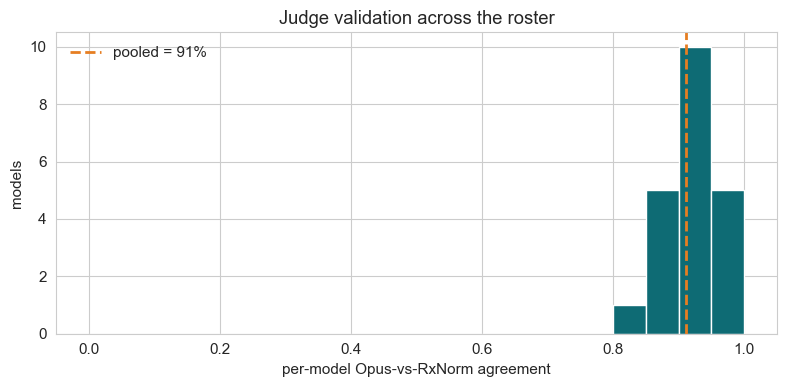

**What this shows:** pooled across the roster, Opus reproduces RxNorm on **91%** of confirmable aliases, and most models sit near that line — the judge is consistently sound, not cherry-picked. Where a model's bar is low, its RxNorm-confirmed set is small and noisy, not evidence the judge failed.

In [3]:

if len(JVM):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(JVM.values, bins=np.linspace(0, 1, 21), color="#0e6b74", edgecolor="white")
    ax.axvline(judge_agree, color="#e67e22", lw=2, ls="--", label=f"pooled = {judge_agree:.0%}")
    ax.set_xlabel("per-model Opus-vs-RxNorm agreement"); ax.set_ylabel("models")
    ax.set_title("Judge validation across the roster"); ax.legend(frameon=False)
    fig.tight_layout(); plt.show()
    display(Markdown(
      f"**What this shows:** pooled across the roster, Opus reproduces RxNorm on **{judge_agree:.0%}** of "
      f"confirmable aliases, and most models sit near that line — the judge is consistently sound, not "
      f"cherry-picked. Where a model's bar is low, its RxNorm-confirmed set is small and noisy, not evidence "
      f"the judge failed."))


## 3. Correctness scorecard — the verdict

Each model's **Opus-precision** (fraction of its aliases the validated judge calls valid), sorted. This is the accuracy column of the scorecard; the RxNorm floor and the full table follow.

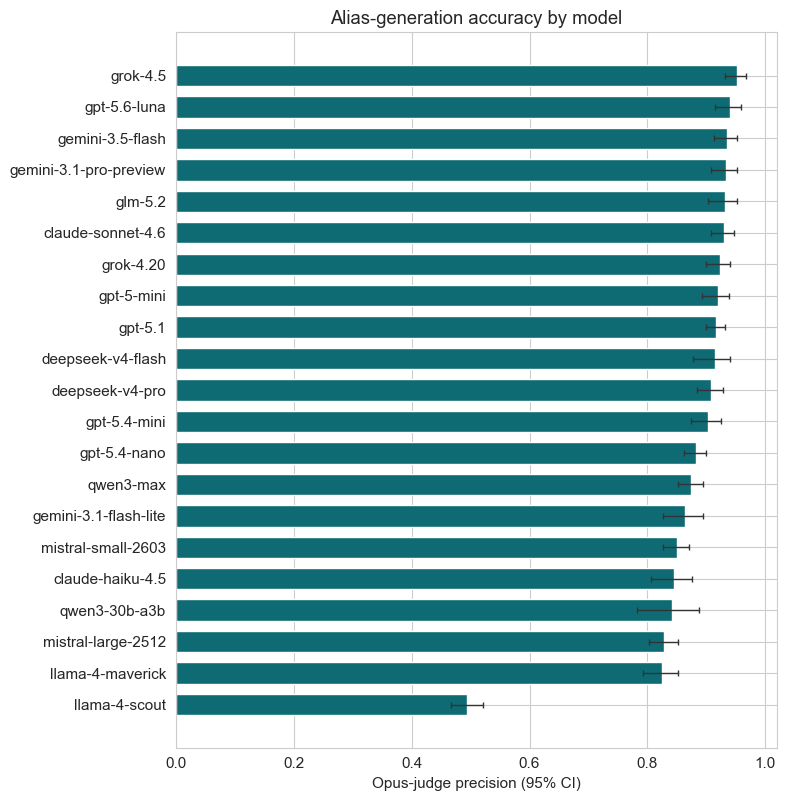

model,Opus acc.,RxNorm floor,brand recall,aliases/drug,$/1M in
grok-4.5,95%,15%,45%,19.8,$2
gpt-5.6-luna,94%,19%,45%,15.5,$1
gemini-3.5-flash,94%,16%,42%,23.1,$1.5
gemini-3.1-pro-preview,93%,19%,45%,19.6,$2
glm-5.2,93%,15%,27%,10.4,$0.906
claude-sonnet-4.6,93%,12%,42%,29.0,$3
grok-4.20,92%,15%,44%,21.9,$1.25
gpt-5-mini,92%,20%,35%,14.1,$0.25
gpt-5.1,92%,9%,45%,29.1,$1.25
deepseek-v4-flash,91%,20%,32%,5.8,$0.098


In [4]:

d = MS.sort_values("opus_prec", ascending=True)
fig, ax = plt.subplots(figsize=(8, 0.34*len(d) + 1))
lo = [wilson_ci(int(r.opus_valid), int(r.opus_valid + r.opus_invalid))[0] for _, r in d.iterrows()]
hi = [wilson_ci(int(r.opus_valid), int(r.opus_valid + r.opus_invalid))[1] for _, r in d.iterrows()]
ax.barh(d.mshort, d.opus_prec, color="#0e6b74", height=0.68)
ax.errorbar(d.opus_prec, range(len(d)), xerr=[d.opus_prec - lo, np.array(hi) - d.opus_prec],
            fmt="none", ecolor="#333", capsize=2, lw=1)
ax.set_xlim(0, 1.02); ax.set_xlabel("Opus-judge precision (95% CI)")
ax.set_title("Alias-generation accuracy by model")
fig.tight_layout(); plt.show()

tbl = MS.sort_values("opus_prec", ascending=False)[
    ["mshort","opus_prec","rx_prec","brand_recall","mean_aliases","price"]].copy()
for c in ["opus_prec","rx_prec","brand_recall"]:
    tbl[c] = (tbl[c]*100).round(0).astype("Int64").astype(str) + "%"
tbl["mean_aliases"] = tbl["mean_aliases"].round(1)
tbl["price"] = tbl["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
tbl.columns = ["model","Opus acc.","RxNorm floor","brand recall","aliases/drug","$/1M in"]
display(HTML("<b>Per-model correctness</b>" + tbl.to_html(index=False)))


## 4. Counterintuitive: the objective database ranks the roster differently

Score the roster by RxNorm and by Opus-judge and the orderings disagree. Models can sit high on RxNorm precision yet low on real accuracy (they stick to formal names but still hallucinate), or low on RxNorm yet high on accuracy (they add *correct* informal aliases RxNorm can't confirm). If you ranked models by the objective database — or by how much they agree with each other — you would pick wrong. Only the validated judge tracks truth.

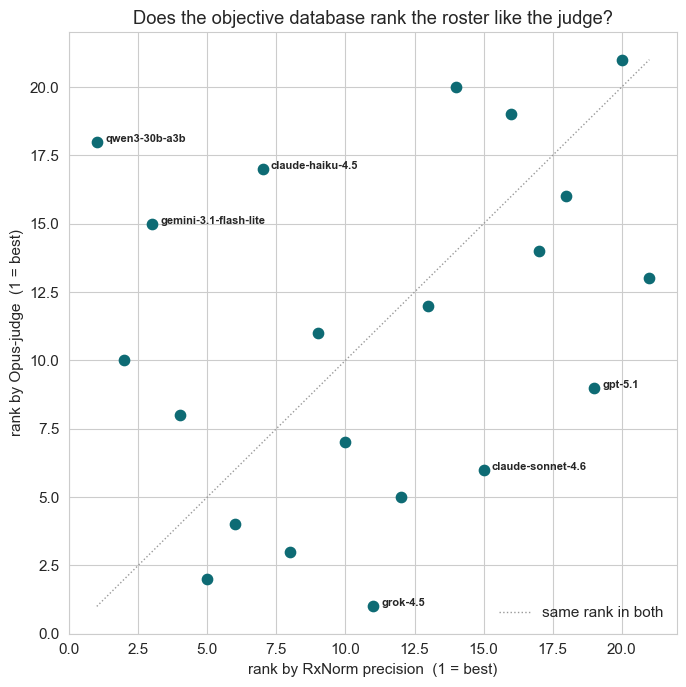

**What this shows:** rank-by-RxNorm against rank-by-Opus (Spearman ρ=0.27). Points off the diagonal are ordered *differently* by the two sources — **qwen3-30b-a3b** moves 17 places between them. A model high-left (good RxNorm rank, poor Opus rank) looks clean in the database but hallucinates; low-right is the reverse — correct informal aliases RxNorm can't confirm. Rank the roster by the database and you order it differently from the validated judge: RxNorm corroborates, it does not rank.

In [5]:

# rank-by-RxNorm vs rank-by-Opus — off-diagonal = the two sources order the roster differently
R = MS.copy()
R["rank_rx"] = R.rx_prec.rank(ascending=False, method="min")
R["rank_op"] = R.opus_prec.rank(ascending=False, method="min")
R["move"] = (R.rank_rx - R.rank_op).abs()
n = len(R)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(R.rank_rx, R.rank_op, s=55, color="#0e6b74", zorder=3)
ax.plot([1, n], [1, n], ls=":", color="#999", lw=1, label="same rank in both")
for _, r in R.nlargest(6, "move").iterrows():
    ax.annotate(r.mshort, (r.rank_rx, r.rank_op), fontsize=8, fontweight="bold",
                xytext=(6, 0), textcoords="offset points")
ax.set_xlabel("rank by RxNorm precision  (1 = best)"); ax.set_ylabel("rank by Opus-judge  (1 = best)")
ax.set_title("Does the objective database rank the roster like the judge?")
ax.legend(frameon=False, loc="lower right"); fig.tight_layout(); plt.show()
srho = spearmanr(MS.rx_prec, MS.opus_prec).correlation
mover = R.nlargest(1, "move").iloc[0]
display(Markdown(
  f"**What this shows:** rank-by-RxNorm against rank-by-Opus (Spearman ρ={srho:.2f}). Points off the diagonal "
  f"are ordered *differently* by the two sources — **{mover.mshort}** moves {int(mover.move)} places between "
  f"them. A model high-left (good RxNorm rank, poor Opus rank) looks clean in the database but hallucinates; "
  f"low-right is the reverse — correct informal aliases RxNorm can't confirm. Rank the roster by the database "
  f"and you order it differently from the validated judge: RxNorm corroborates, it does not rank."))


## 5. Comparing the models to each other — divergence map

Correctness says who is *right*; divergence says who *behaves alike*. The matrix is the mean Jaccard of alias sets between every pair of models (1 = identical sets). It clusters the roster into behaviour groups and exposes outliers — but note the caveat: agreeing models can share the same bias, so divergence is a diagnostic, never a correctness verdict.

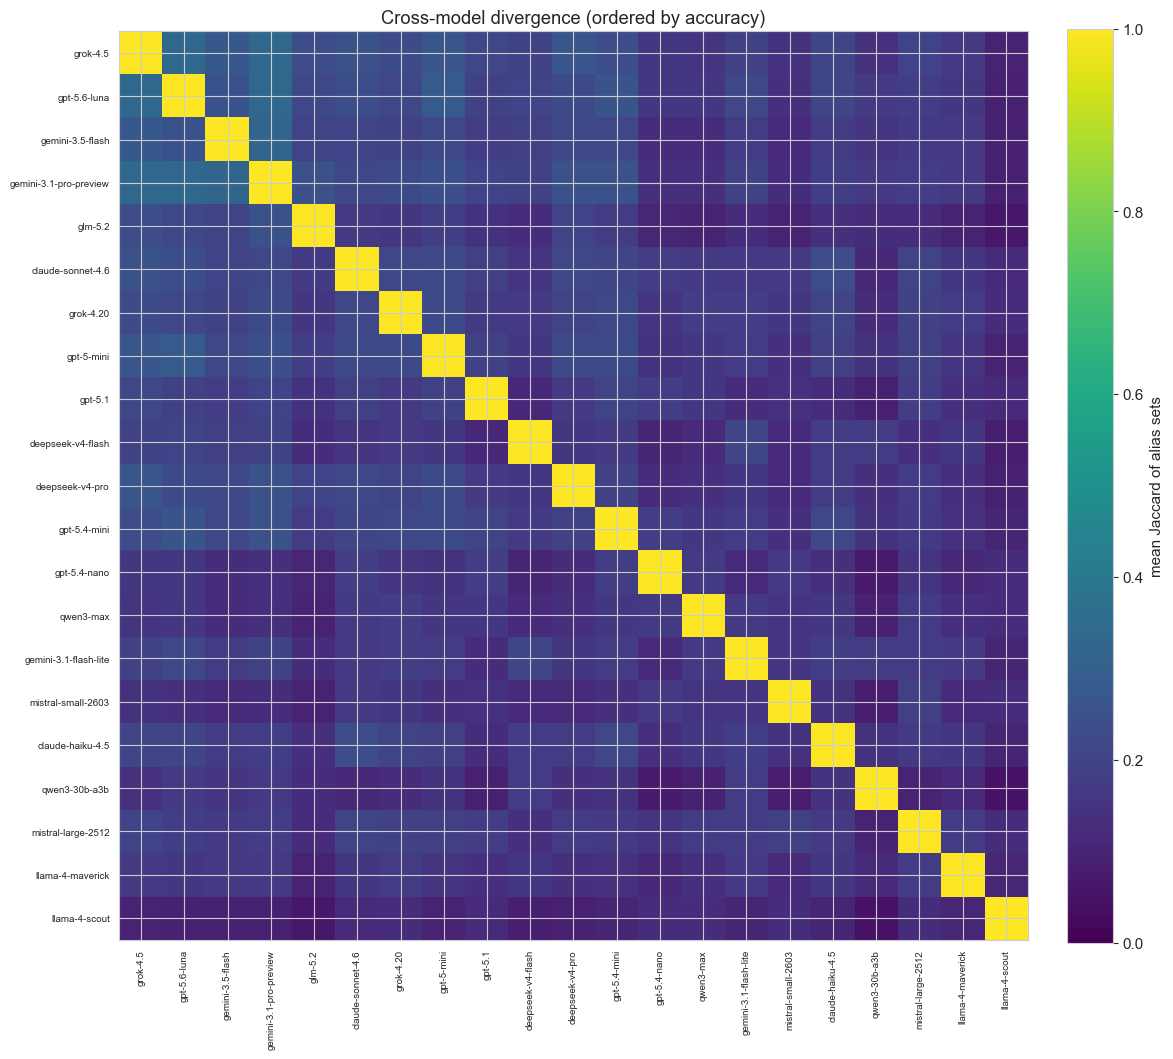

model,outlier score (1 − mean agreement),Opus acc.
llama-4-scout,0.90,49%
qwen3-30b-a3b,0.87,84%
mistral-small-2603,0.86,85%
gpt-5.4-nano,0.86,88%
llama-4-maverick,0.85,82%
qwen3-max,0.85,87%
glm-5.2,0.85,93%
deepseek-v4-flash,0.84,91%


**What this shows:** the roster shares a mean **17%** alias overlap. The most *divergent* model is **llama-4-scout** — but divergence alone is not a fault: read it against §3, an outlier that is *also* low-accuracy is a problem; an outlier that stays accurate just formats aliases differently.

In [6]:

order = MS.sort_values("opus_prec", ascending=False).mshort.tolist()
M = MAT.reindex(index=order, columns=order).astype(float)
fig, ax = plt.subplots(figsize=(0.42*len(order) + 3, 0.42*len(order) + 2))
im = ax.imshow(M.values, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean Jaccard of alias sets")
ax.set_title("Cross-model divergence (ordered by accuracy)")
fig.tight_layout(); plt.show()

od = MS.sort_values("outlier", ascending=False)[["mshort","outlier","opus_prec"]].head(8).copy()
od["outlier"] = od["outlier"].round(2); od["opus_prec"] = (od["opus_prec"]*100).round(0).astype("Int64").astype(str)+"%"
od.columns = ["model","outlier score (1 − mean agreement)","Opus acc."]
display(HTML("<b>Most divergent models</b>" + od.to_html(index=False)))
display(Markdown(
  f"**What this shows:** the roster shares a mean **{np.nanmean(MAT.values[np.triu_indices(len(order),1)]):.0%}** "
  f"alias overlap. The most *divergent* model is **{od.iloc[0]['model']}** — but divergence alone is not a "
  f"fault: read it against §3, an outlier that is *also* low-accuracy is a problem; an outlier that stays "
  f"accurate just formats aliases differently."))


## 6. Conclusion & scorecard — accuracy per dollar

The payoff: the full scorecard, and the one number the project turns on — the cheapest model whose accuracy is close to the best (the design's *closest-to-Opus-per-dollar*).

In [7]:

best_acc = MS.opus_prec.max()
elig = MS[MS.opus_prec >= best_acc - 0.05].copy()  # within 5 points of the best
pick = elig.sort_values("price").iloc[0] if elig.price.notna().any() else MS.sort_values("opus_prec", ascending=False).iloc[0]

sc = MS.sort_values("opus_prec", ascending=False)[
    ["mshort","opus_prec","rx_prec","outlier","self_jaccard","mean_aliases","price"]].copy()
sc["opus_prec"] = (sc["opus_prec"]*100).round(0).astype("Int64").astype(str)+"%"
sc["rx_prec"] = (sc["rx_prec"]*100).round(0).astype("Int64").astype(str)+"%"
sc["outlier"] = sc["outlier"].round(2)
sc["self_jaccard"] = sc["self_jaccard"].round(2)
sc["mean_aliases"] = sc["mean_aliases"].round(1)
sc["price"] = sc["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
sc.columns = ["model","accuracy (Opus)","RxNorm floor","divergence","self-consist (k)","aliases/drug","$/1M in"]
display(HTML("<b>① alias — full scorecard</b>" + sc.to_html(index=False)))

lines = [
  f"- **Most accurate:** {MS.sort_values('opus_prec', ascending=False).iloc[0].mshort} "
  f"({best_acc:.0%} valid). This is the accuracy anchor for the scorecard.",
  f"- **Best value (closest to top accuracy per dollar):** **{pick.mshort}** — {pick.opus_prec:.0%} accuracy "
  f"at ${pick.price:g}/1M input" + (", within 5 points of the best while cheaper." if pick.opus_prec < best_acc else "."),
  f"- **Judge is sound** ({judge_agree:.0%} vs RxNorm), so these are correctness numbers, not agreement.",
  f"- **RxNorm is a floor, divergence is a diagnostic** — neither ranks the roster; the Opus column does.",
  f"- **Alias generation is unstable even at temp 0** — mean run-to-run self-Jaccard "
  f"{MS.self_jaccard.mean():.2f}, so K=5 is necessary, not optional.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


model,accuracy (Opus),RxNorm floor,divergence,self-consist (k),aliases/drug,$/1M in
grok-4.5,95%,15%,0.78,0.55,19.8,$2
gpt-5.6-luna,94%,19%,0.79,0.53,15.5,$1
gemini-3.5-flash,94%,16%,0.81,NaN,23.1,$1.5
gemini-3.1-pro-preview,93%,19%,0.79,NaN,19.6,$2
glm-5.2,93%,15%,0.85,NaN,10.4,$0.906
claude-sonnet-4.6,93%,12%,0.81,0.66,29.0,$3
grok-4.20,92%,15%,0.81,0.55,21.9,$1.25
gpt-5-mini,92%,20%,0.81,NaN,14.1,$0.25
gpt-5.1,92%,9%,0.84,0.32,29.1,$1.25
deepseek-v4-flash,91%,20%,0.84,NaN,5.8,$0.098


### Verdict

- **Most accurate:** grok-4.5 (95% valid). This is the accuracy anchor for the scorecard.
- **Best value (closest to top accuracy per dollar):** **deepseek-v4-flash** — 91% accuracy at $0.098/1M input, within 5 points of the best while cheaper.
- **Judge is sound** (91% vs RxNorm), so these are correctness numbers, not agreement.
- **RxNorm is a floor, divergence is a diagnostic** — neither ranks the roster; the Opus column does.
- **Alias generation is unstable even at temp 0** — mean run-to-run self-Jaccard 0.49, so K=5 is necessary, not optional.

## 7. Research limitations

- **Opus-as-truth is silver, not gold.** It is a model grading models; we validated it against RxNorm on
  the covered subset (§2), but on genuinely ambiguous informal aliases it is a judgment. RxNorm covers only
  formal names and even misses some real brands, so its "floor" is thin.
- **Slugs drift.** The roster was resolved against the live OpenRouter catalogue on the run date; re-confirm
  before re-running. Models that returned no parseable aliases are listed in the abstract and excluded.
- **Drug set** is 16 curated real drugs + one supplement; accuracy on obscure supplements (no RxNorm anchor)
  leans entirely on Opus and deserves more caution.
- **Price** is input $/1M-tokens from the catalogue and ignores output tokens and latency; treat it as an
  order-of-magnitude cost signal, not a bill.
- This notebook measures the correctness of a measurement step, not any treatment effect.

In [8]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
prov = pd.DataFrame({
  "item": ["run generated (UTC)","judgement","candidate models","judge (truth)","truth sources",
           "drugs / k","temperature","skill version"],
  "value": [MAN["generated_utc"], MAN["judgement"], f'{len(CAND)} ({len(OK)} produced aliases)',
            MAN["judge_model"], ", ".join(MAN["truth_sources"]), f'{MAN["n_drugs"]} / {MAN["k"]}',
            MAN["temperature"], "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the behaviour of a measurement pipeline and model knowledge, not '
             'population-level treatment effects. This is not medical advice.</div>'))


item,value
run generated (UTC),2026-07-18T01:01:46.484050+00:00
judgement,1_alias_generation
candidate models,22 (21 produced aliases)
judge (truth),anthropic/claude-opus-4.8
truth sources,"rxnorm, opus_judge"
drugs / k,16 / 5
temperature,0.0
skill version,research-assistant v2
